# 📊 Superstore Sales Data Visualization

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

df = pd.read_parquet('Superstore_Engineered.parquet')
df.head(3)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Profit,Outlier_Flag,Order_Year,Order_Quarter,Order_Month,Order_Month_Name,Year_Month,Shipping_Duration,Profit_Margin,Is_Loss
0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,41.9136,False,2018,4,11,November,2018-11,3,0.16,False
1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,219.5820,True,2018,4,11,November,2018-11,3,0.30,False
2,CA-2018-138688,2018-06-12,2018-06-16,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,6.8714,False,2018,2,6,June,2018-06,4,0.47,False


## Visualization 1: Sales & Profit Trend Over Time (Year-Month)

**Business insight:** Shows overall growth trajectory and seasonal peaks.


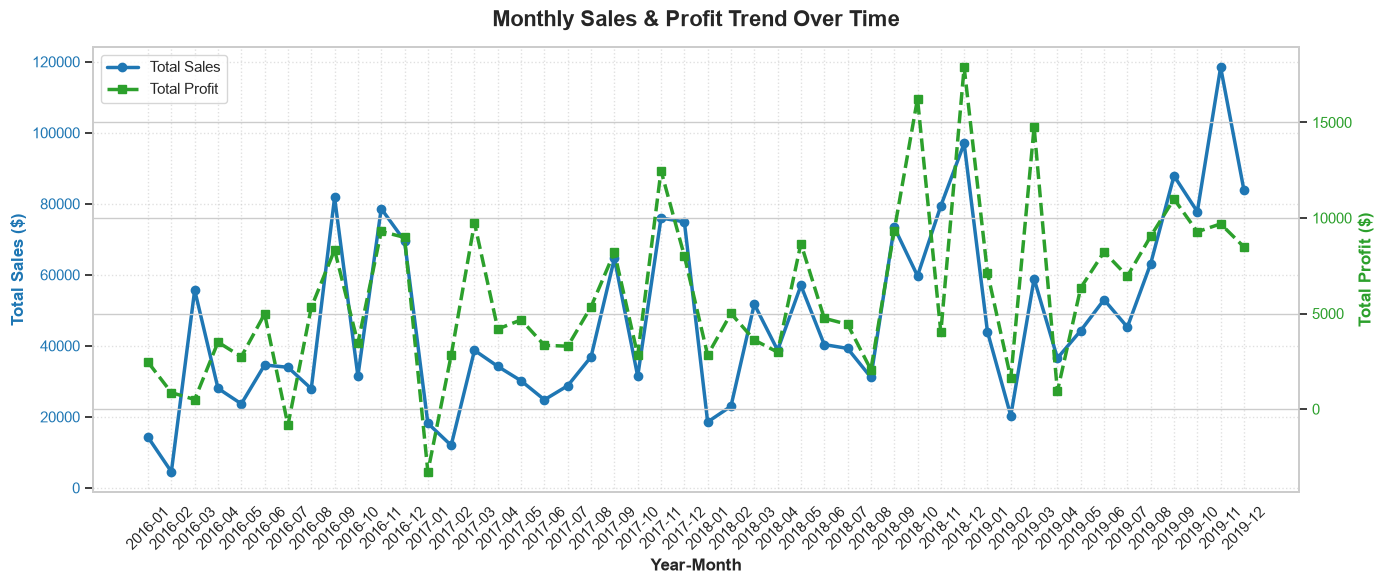

In [10]:
# 1. Group data by Year-Month to calculate Total Sales and Total Profit
monthly_trend = df.groupby('Year_Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# 2. Setup the plot with dual Y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary Axis (Left) for Total Sales
color_sales = '#1f77b4' # Professional Blue
ax1.set_xlabel('Year-Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', color=color_sales, fontsize=12, fontweight='bold')
line1 = ax1.plot(monthly_trend['Year_Month'], monthly_trend['Total_Sales'], 
                 color=color_sales, marker='o', linewidth=2.5, label='Total Sales')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.tick_params(axis='x', rotation=45)

# Secondary Axis (Right) for Total Profit
ax2 = ax1.twinx()
color_profit = '#2ca02c' # Professional Green
ax2.set_ylabel('Total Profit ($)', color=color_profit, fontsize=12, fontweight='bold')
line2 = ax2.plot(monthly_trend['Year_Month'], monthly_trend['Total_Profit'], 
                 color=color_profit, marker='s', linewidth=2.5, linestyle='--', label='Total Profit')
ax2.tick_params(axis='y', labelcolor=color_profit)

# Styling and Labels
plt.title('Monthly Sales & Profit Trend Over Time', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Combine legends for both axes into one box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## Visualization 2: Category Performance - Sales vs Profit (Grouped Bar)

**Business insight:** Technology leads in both sales and profit; Furniture has weaker profitability.


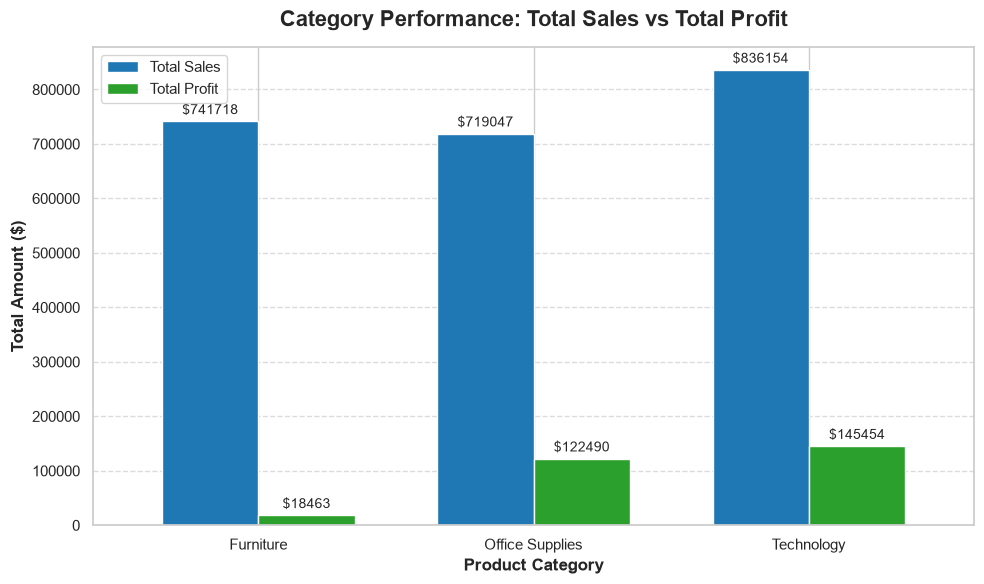

In [11]:
# 1. Group data by Category for Sales and Profit
category_perf = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the grouped bar chart using pandas built-in plot
# '#1f77b4' is blue for Sales, '#2ca02c' is green for Profit
category_perf.plot(kind='bar', ax=ax, color=['#1f77b4', '#2ca02c'], width=0.7)

# 4. Styling the chart
plt.title('Category Performance: Total Sales vs Total Profit', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Amount ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11) # Keep category names horizontal
plt.legend(['Total Sales', 'Total Profit'], loc='upper left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add data labels on top of each bar (Professional touch)
for container in ax.containers:
    ax.bar_label(container, fmt='$%d', label_type='edge', padding=3, fontsize=10)

# 6. Display the chart
plt.tight_layout()
plt.show()

## Visualization 3: Profit Margin Distribution by Category (Violin + Box)

**Business insight:** Office Supplies shows tight positive margins; Furniture has long negative tail.


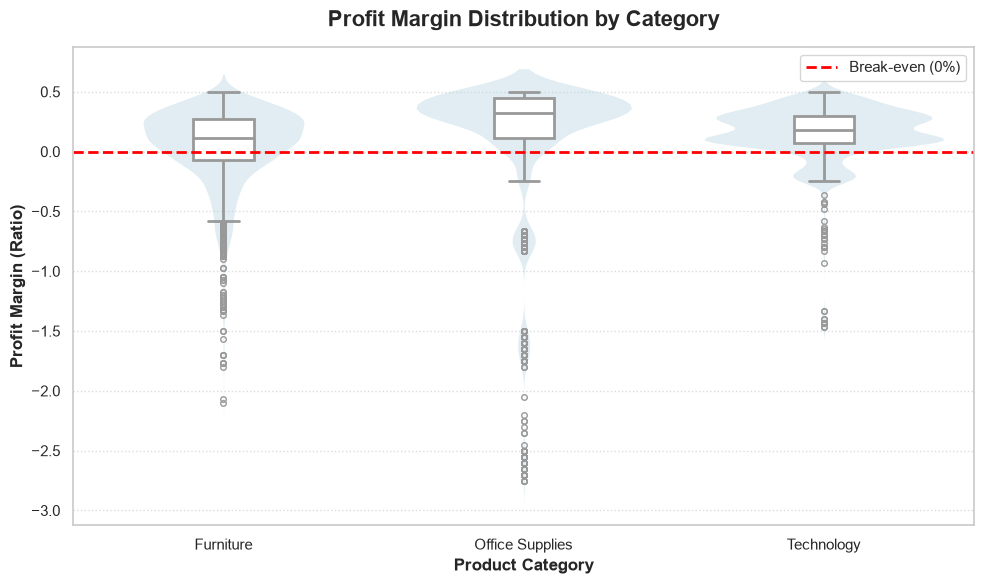

In [14]:
# 1. Setup the figure size
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the Violin plot (Shows the overall shape and density of the distribution)
# We set inner=None because we will draw our own clean Boxplot inside it
sns.violinplot(
    x='Category', 
    y='Profit_Margin', 
    data=df, 
    inner=None, 
    color='lightblue', 
    linewidth=0,
    alpha=0.4,
    ax=ax
)

# 3. Overlay the Box plot (Shows median, quartiles, and exact outliers)
sns.boxplot(
    x='Category', 
    y='Profit_Margin', 
    data=df, 
    width=0.2, 
    color='white',
    linewidth=2,
    fliersize=4,
    ax=ax
)

# 4. Add a crucial horizontal line at 0 margin (Break-even point)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Break-even (0%)')

# 5. Styling the chart
plt.title('Profit Margin Distribution by Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Profit Margin (Ratio)', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# 6. Display the chart
plt.tight_layout()
plt.show()

## Visualization 4: Regional Heatmap - Sales & Profit by Region x Segment

**Business insight:** West + Consumer is the strongest combination; Central has weaker profit.


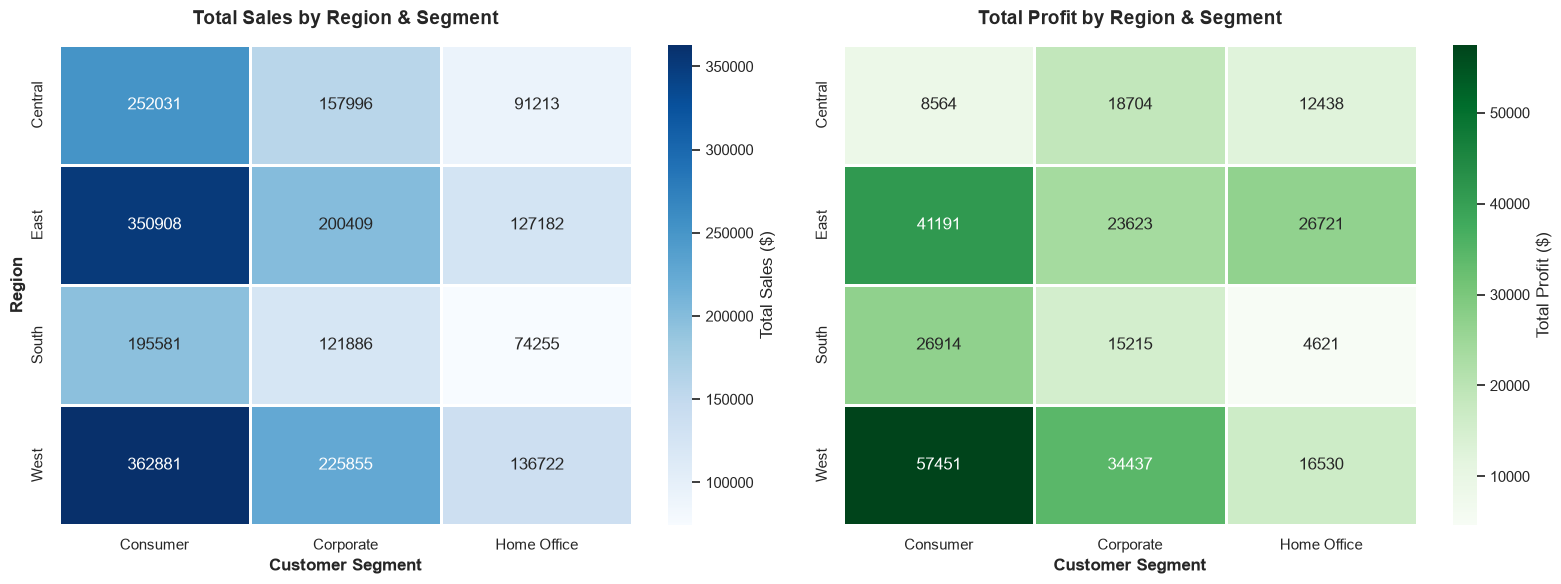

In [17]:
# 1. Prepare data for Heatmaps using Pivot Tables
sales_pivot = df.pivot_table(index='Region', columns='Segment', values='Sales', aggfunc='sum')
profit_pivot = df.pivot_table(index='Region', columns='Segment', values='Profit', aggfunc='sum')

# 2. Setup the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Draw Sales Heatmap (Left)
sns.heatmap(
    sales_pivot, 
    annot=True, 
    fmt=".0f", 
    cmap="Blues", 
    linewidths=1, 
    cbar_kws={'label': 'Total Sales ($)'},
    ax=axes[0]
)
axes[0].set_title('Total Sales by Region & Segment', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Region', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Segment', fontsize=12, fontweight='bold')

# 4. Draw Profit Heatmap (Right)
sns.heatmap(
    profit_pivot, 
    annot=True, 
    fmt=".0f", 
    cmap="Greens", 
    linewidths=1, 
    cbar_kws={'label': 'Total Profit ($)'},
    ax=axes[1]
)
axes[1].set_title('Total Profit by Region & Segment', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('') # Hide ylabel to keep it clean
axes[1].set_xlabel('Customer Segment', fontsize=12, fontweight='bold')

# 5. Display the charts
plt.tight_layout()
plt.show()

## Visualization 5: Discount vs Profit Margin Scatter

**Business insight:** Clear negative relationship - deep discounts destroy margins.


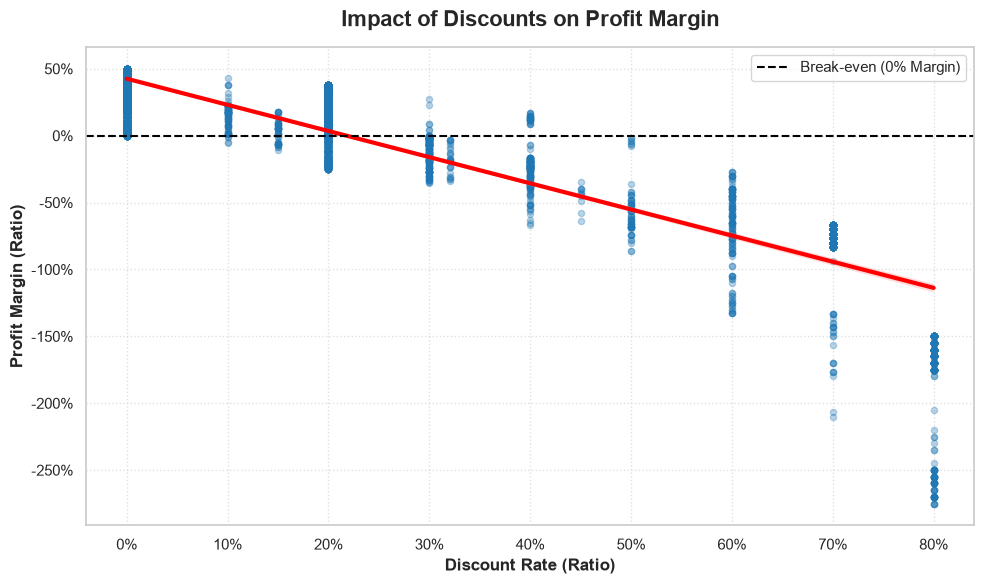

In [19]:
# 1. Setup the figure size
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the Scatter plot with a Regression line (regplot)
sns.regplot(
    x='Discount', 
    y='Profit_Margin', 
    data=df, 
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4', 's': 20}, # Blue dots, slightly transparent
    line_kws={'color': 'red', 'linewidth': 3}, # Bold red trend line
    ax=ax
)

# 3. Add a horizontal line at 0 (Break-even point) to clearly show losses
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Break-even (0% Margin)')

# 4. Styling the chart
plt.title('Impact of Discounts on Profit Margin', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Discount Rate (Ratio)', fontsize=12, fontweight='bold')
plt.ylabel('Profit Margin (Ratio)', fontsize=12, fontweight='bold')

# 5. Format X-axis to show percentages nicely (e.g., 0.20 as 20%)
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# 6. Display the chart
plt.tight_layout()
plt.show()

## Visualization 6: Top 10 Sub-Categories by Sales (Horizontal Bar)

**Business insight:** Phones, Chairs, Storage lead sales; Tables often unprofitable.


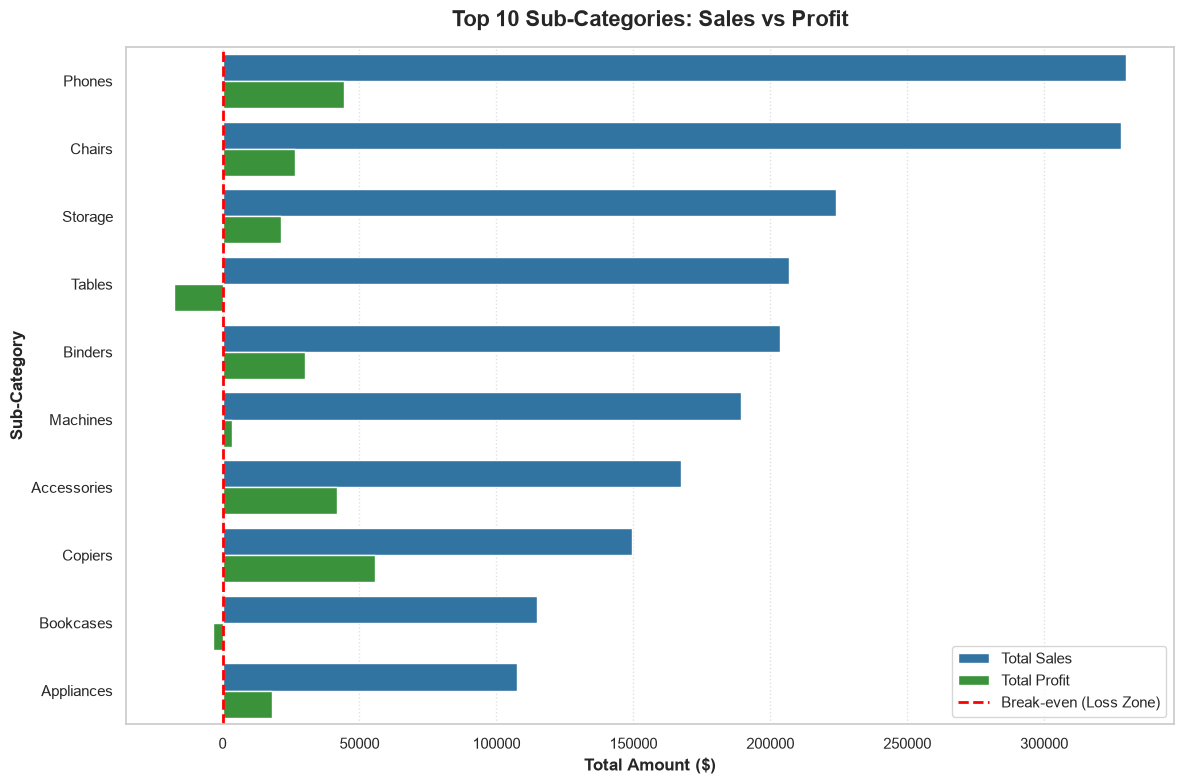

In [22]:
# 1. Prepare the data: Group by Sub-Category, calculate Sales & Profit, sort by Sales, take Top 10
top_10_subcats = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values(by='Total_Sales', ascending=False).head(10).reset_index()

# 2. Reshape the data for plotting using Pandas 'melt' (makes it easy to plot grouped bars)
top_10_melted = top_10_subcats.melt(
    id_vars='Sub-Category', 
    value_vars=['Total_Sales', 'Total_Profit'], 
    var_name='Metric', 
    value_name='Amount'
)

# 3. Setup the figure size
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Draw the Horizontal Bar chart
# Using blue for Sales and red/green logic would be complex in a single hue, 
# so we stick to professional Blue (Sales) and Green (Profit)
sns.barplot(
    x='Amount', 
    y='Sub-Category', 
    hue='Metric', 
    data=top_10_melted, 
    palette=['#1f77b4', '#2ca02c'], 
    ax=ax
)

# 5. Add a vertical red dashed line at 0 to clearly expose the negative profit (Tables)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even (0 Profit)')

# 6. Styling the chart
plt.title('Top 10 Sub-Categories: Sales vs Profit', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Amount ($)', fontsize=12, fontweight='bold')
plt.ylabel('Sub-Category', fontsize=12, fontweight='bold')

# Clean up the legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Total Sales', 'Total Profit', 'Break-even (Loss Zone)'], loc='lower right', fontsize=11)

plt.grid(axis='x', linestyle=':', alpha=0.6)

# 7. Display the chart
plt.tight_layout()
plt.show()

## Visualization 7: Shipping Duration Distribution by Ship Mode (Box Plot)

**Business insight:** Same Day is fastest; Standard Class has widest spread and longest median.


C:\Users\Reem\AppData\Local\Temp\ipykernel_17948\1382183755.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


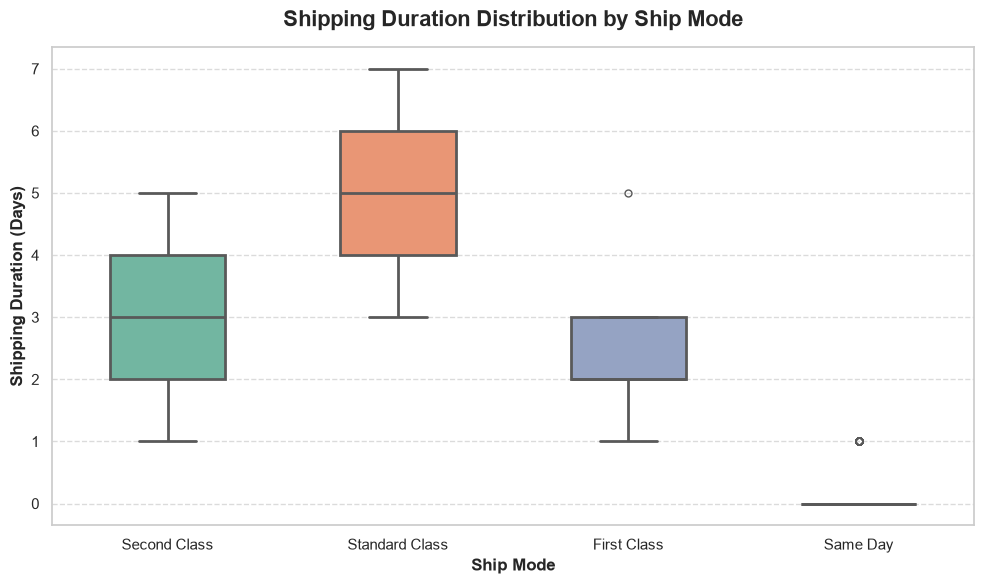

In [ ]:
# 1. Setup the figure size
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the Box Plot
# Using a specific color palette 'Set2' for a clean, professional look
sns.boxplot(
    x='Ship Mode', 
    y='Shipping_Duration', 
    data=df, 
    palette='Set2', 
    width=0.5,
    linewidth=2,
    fliersize=5, # Make outliers a bit larger
    ax=ax
)

# 3. Styling the chart
plt.title('Shipping Duration Distribution by Ship Mode', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ship Mode', fontsize=12, fontweight='bold')
plt.ylabel('Shipping Duration (Days)', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Display the chart
plt.tight_layout()
plt.show()

## Visualization 8: Correlation Heatmap of Key Metrics

**Business insight:** Strong negative correlation between Discount and Profit/Margin; Sales positively linked to Profit.


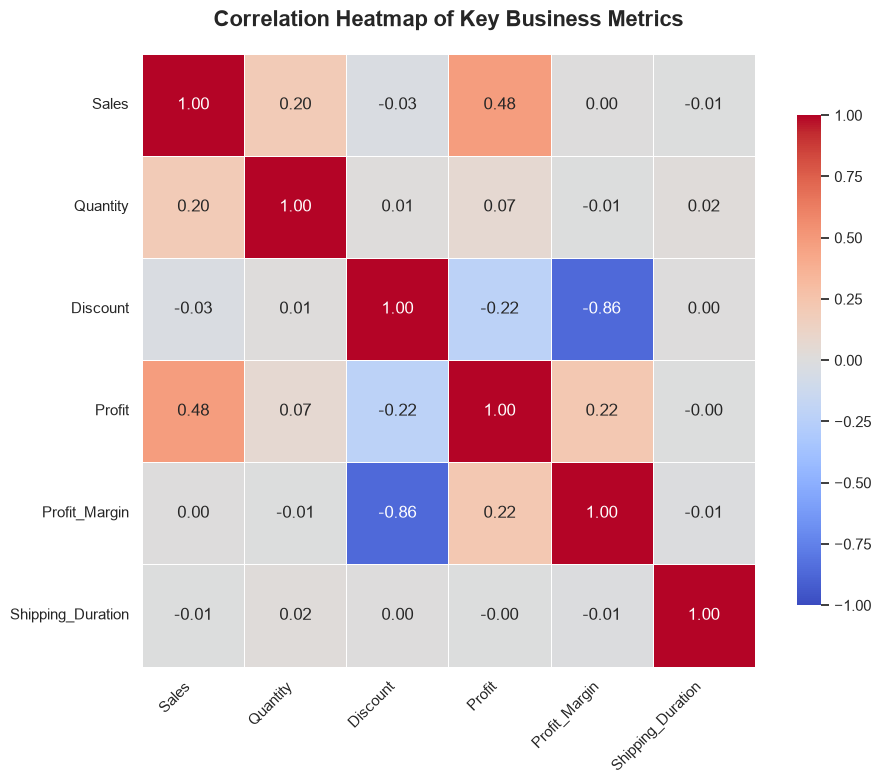

In [15]:
# 1. Select only the numerical columns relevant for correlation
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin', 'Shipping_Duration']
correlation_matrix = df[num_cols].corr()

# 2. Setup the plot size
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Draw the Heatmap
# annot=True shows the exact numbers, cmap='coolwarm' gives clear red(negative)/blue(positive) colors
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8},
    ax=ax
)

# 4. Styling the chart
plt.title('Correlation Heatmap of Key Business Metrics', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# 5. Display the chart
plt.tight_layout()
plt.show()